# Проверка гипотезы № 6 - Лучшие способы моделировать сезонность

Я решила взять на проверку гипотезу № 6 (моделирование сезонности), так как в анализе временных рядов сезонность играет одну из ключевых ролей. В России это особенно актуально, так как у нас сезоны различаются кардинально.

## Установка и импорт библиотек

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# так как работаю в колабе, то привязала папку с ру файлами для работы с ними
import sys
sys.path.append('/content/drive/MyDrive/project')

In [2]:
# установлю все требуемые либы для анализа (чтобы работали импорты в run_experiment.py)
%%capture install_log
!pip install -q \
    'pandas>=2.0' \
    'numpy>=1.24' \
    'scikit-learn>=1.3' \
    'catboost>=1.2' \
    'statsforecast>=1.7' \
    'statsmodels>=0.14' \
    'matplotlib>=3.7' \
    'seaborn>=0.12' \
    'tqdm>=4.65' \
    'scipy>=1.11'

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import Image, display

sns.set_theme(style='whitegrid', palette='muted')

# импортирую все необходимые конфиги из файла config.py
from config import (
    RESULTS_DIR, DATA_DIR,
    M4_TSF_URL, TSF_FILE_NAME,
    N_SERIES, RANDOM_SEED, MIN_SERIES_LEN,
    SEASONALITY, ACF_LAG, ACF_THRESHOLD,
    HORIZONS, DEFAULT_HORIZON,
    FEATURE_VARIANTS,
    N_LAGS, SEASONAL_LAGS, N_FOURIER_TERMS,
    CATBOOST_PARAMS, STRENGTH_BINS,
)

# импортировала функции для запуска из файла run_experiment.py
from run_experiment import (
    convert_tsf_to_dataframe,
    load_m4_monthly_tsf,
    sample_and_filter,
    annotate_series,
    filter_seasonal,
    run_baselines,
    run_all_catboost,
    summary_table,
    plot_metric_comparison,
    plot_acf_distribution,
    analyse_by_strength,
    analyse_by_horizon,
    correlation_strength_vs_improvement,
    main
)

# папка с результатами
RESULTS = Path(RESULTS_DIR)
RESULTS.mkdir(exist_ok=True)

rng = np.random.default_rng(RANDOM_SEED)

print('Конфигурация и функции загружены')
print(f'  Сезонность в месяцах = {SEASONALITY}, Горизонт = {DEFAULT_HORIZON}')

Видеокарта не обнаружена, CatBoost на CPU
Конфигурация и функции загружены
  Сезонность в месяцах = 12, Горизонт = 18


## 1. Загрузка данных M4 Monthly и сэмплирование

In [3]:
# загрузка данных из подготовленной папки с файлом tsf
full_series = load_m4_monthly_tsf()

# так как формат tsf содержит полные ряды,
# я могу сразу приступать к сэмплированию и фильтрации, взяла 350 рядов
series_dict = sample_and_filter(full_series)

print(f'Всего временных рядов в исходном датасете: {len(full_series)}')
print(f'Выбрано для эксперимента (после фильтрации по длине и сэмплирования): {len(series_dict)}')

Файл найден. Начинаю парсинг m4_monthly_dataset.tsf
Всего временных рядов в исходном датасете: 48000
Выбрано для эксперимента (после фильтрации по длине и сэмплирования): 500


## 2. Определение сезонности (ACF)

  Серии с видимой сезонностью: 438 / 500
Рядов с заметной сезонностью (|ACF(12)| >= 0.3): 438
График сохранен в: /content/drive/MyDrive/results/acf_distribution.png


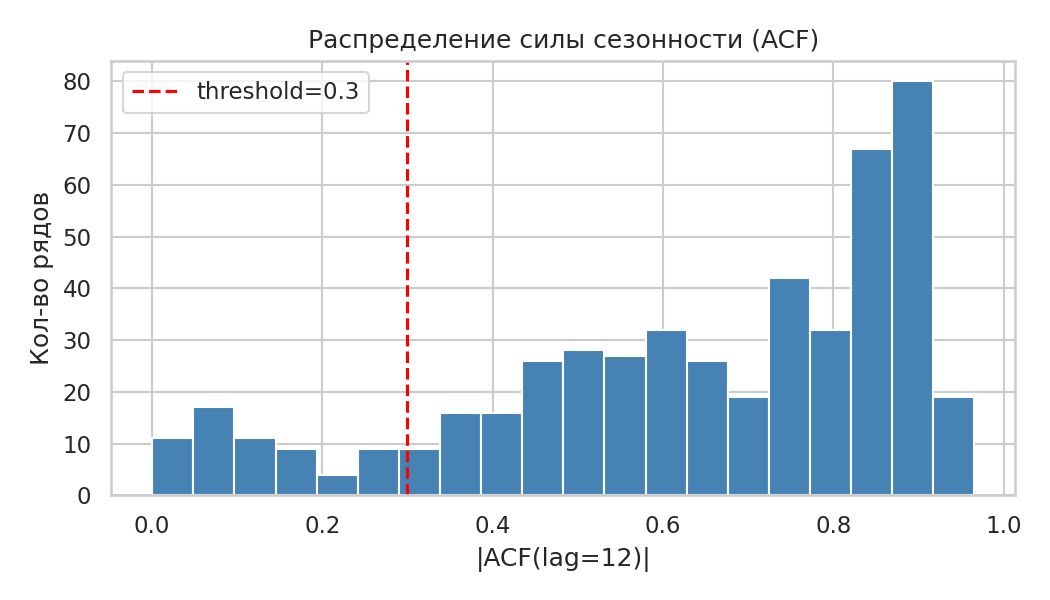

In [4]:
from IPython.display import Image, display

# вычисление силы сезонности и отбор сезонных рядов
meta = annotate_series(series_dict)

series_seasonal, meta_seasonal = filter_seasonal(series_dict, meta)
meta_seasonal.to_csv(RESULTS / 'series_metadata.csv', index=True)

# делаю отбор рядов с учетом порога в 0,3
print(f'Рядов с заметной сезонностью (|ACF({ACF_LAG})| >= {ACF_THRESHOLD}): {len(series_seasonal)}')
plot_acf_distribution(meta, RESULTS / 'acf_distribution.png')

# отображение графика из папки results
display(Image(filename=RESULTS / 'acf_distribution.png'))

## 3. Метрики и базовые модели, инжиниринг фичей и Кэтбуст

In [4]:
# запуск всех вариантов CatBoost (с горизонтами = 3, 6, 18)
# запуск всего эксперимента через функцию main
# порядок проведения экспериментов: очистка -> расчет -> объединение -> сохранение
main()
# будет отображена итоговая таблица с результатами

Запуск эксперимента (Seed: 42) 
Файл найден. Начинаю парсинг m4_monthly_dataset.tsf
График сохранен в: /content/drive/MyDrive/results/acf_distribution.png
  Серии с видимой сезонностью: 438 / 500
  Запуск бейзлайнов (h=18) 
Обучение глобальной модели (вариант: lags_only)...
Обучение глобальной модели (вариант: lags_seasonal)...
Обучение глобальной модели (вариант: lags_calendar)...
Обучение глобальной модели (вариант: lags_fourier)...
Обучение глобальной модели (вариант: lags_seasonal_calendar)...
Обучение глобальной модели (вариант: lags_fourier_calendar)...
График сохранен в: /content/drive/MyDrive/results/all_models_comparison.png
График сохранен в: /content/drive/MyDrive/results/smape_comparison.png

Итоговая таблица результатов 
                                 MASE_mean  MASE_median  RMSSE_mean  \
model                                                                 
AutoTheta                           0.9244       0.7471      0.8245   
AutoETS                             0.9324 

## 4. Сводная таблица с результатами экспериментов

In [5]:
# сделаю саммари по результатам
summary_path = RESULTS / 'summary_metrics.csv'
if summary_path.exists():
    print("\nИтоговые метрики:")
    df_summary = pd.read_csv(summary_path)
    display(df_summary)


Итоговые метрики:


,model,MASE_mean,MASE_median,RMSSE_mean,RMSSE_median,sMAPE_mean,sMAPE_median
0,AutoTheta,0.9244,0.7471,0.8245,0.6913,11.0521,5.5212
1,AutoETS,0.9324,0.7467,0.8235,0.6779,11.8718,5.7060
2,Naive,1.1479,0.8782,1.0331,0.8182,12.7741,7.0503
3,CatBoost_lags_seasonal_calendar,1.1767,0.9190,1.0515,0.8541,12.1442,7.6496
4,CatBoost_lags_fourier_calendar,1.1793,0.9340,1.0530,0.8422,12.0844,7.8094
5,CatBoost_lags_calendar,1.1841,0.9350,1.0580,0.8444,12.0476,7.9248
6,CatBoost_lags_seasonal,1.2030,0.9940,1.0725,0.8892,12.1658,7.5625
7,CatBoost_lags_only,1.2074,0.9654,1.0737,0.8672,12.1031,7.6201
8,CatBoost_lags_fourier,1.2181,0.9331,1.0850,0.8705,12.0517,7.7244
9,SeasonalNaive,1.2558,1.0258,1.0946,0.9422,14.2538,8.1568


In [6]:
# объединение результатов в сводную таблицу
df_from_file = pd.read_csv(RESULTS_DIR / "summary_metrics.csv")
tbl = summary_table(df_from_file)

print("Сводная таблица (сортировка по mean MASE):")
display(tbl.style.format("{:.4f}").background_gradient(cmap='RdYlGn_r'))

Сводная таблица (сортировка по mean MASE):


,MASE_mean,MASE_median,RMSSE_mean,RMSSE_median,sMAPE_mean,sMAPE_median
model,,,,,,
AutoTheta,0.9244,0.7471,0.8245,0.6913,11.0521,5.5212
AutoETS,0.9324,0.7467,0.8235,0.6779,11.8718,5.7060
Naive,1.1479,0.8782,1.0331,0.8182,12.7741,7.0503
CatBoost_lags_seasonal_calendar,1.1767,0.9190,1.0515,0.8541,12.1442,7.6496
CatBoost_lags_fourier_calendar,1.1793,0.9340,1.0530,0.8422,12.0844,7.8094
CatBoost_lags_calendar,1.1841,0.9350,1.0580,0.8444,12.0476,7.9248
CatBoost_lags_seasonal,1.2030,0.9940,1.0725,0.8892,12.1658,7.5625
CatBoost_lags_only,1.2074,0.9654,1.0737,0.8672,12.1031,7.6201
CatBoost_lags_fourier,1.2181,0.9331,1.0850,0.8705,12.0517,7.7244


In [7]:
# сделала еще описательную статистики по рядам
df_series = pd.read_csv(RESULTS_DIR / "series_metadata.csv")

tbl = df_series[['length', 'acf_strength']].describe().round(4).T

print("Описательная статистика:")
display(tbl.style.format("{:.4f}").background_gradient(cmap='RdYlGn_r'))

Описательная статистика:


,count,mean,std,min,25%,50%,75%,max
length,438.0000,258.2785,143.5784,81.0000,122.0000,256.5000,324.0000,1092.0000
acf_strength,438.0000,0.7036,0.1767,0.3004,0.5632,0.7497,0.8620,0.9655


## 5. Графики


 Визуализация результатов 


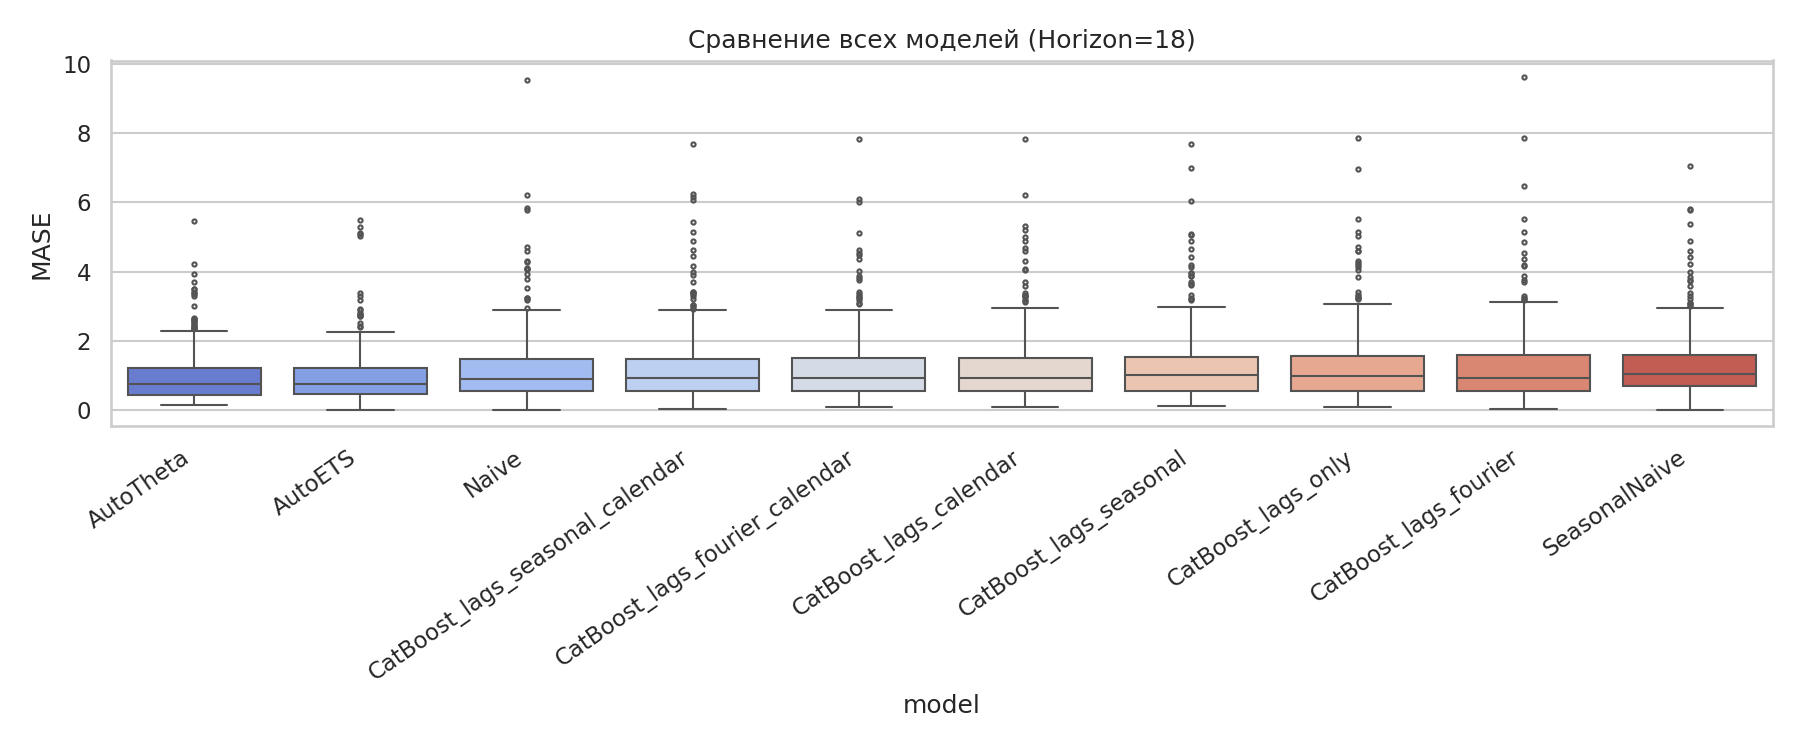

In [8]:
# график сравнения всех моделей (MASE)
print("\n Визуализация результатов ")
display (Image(filename=RESULTS / 'all_models_comparison.png'))


 Визуализация результатов 


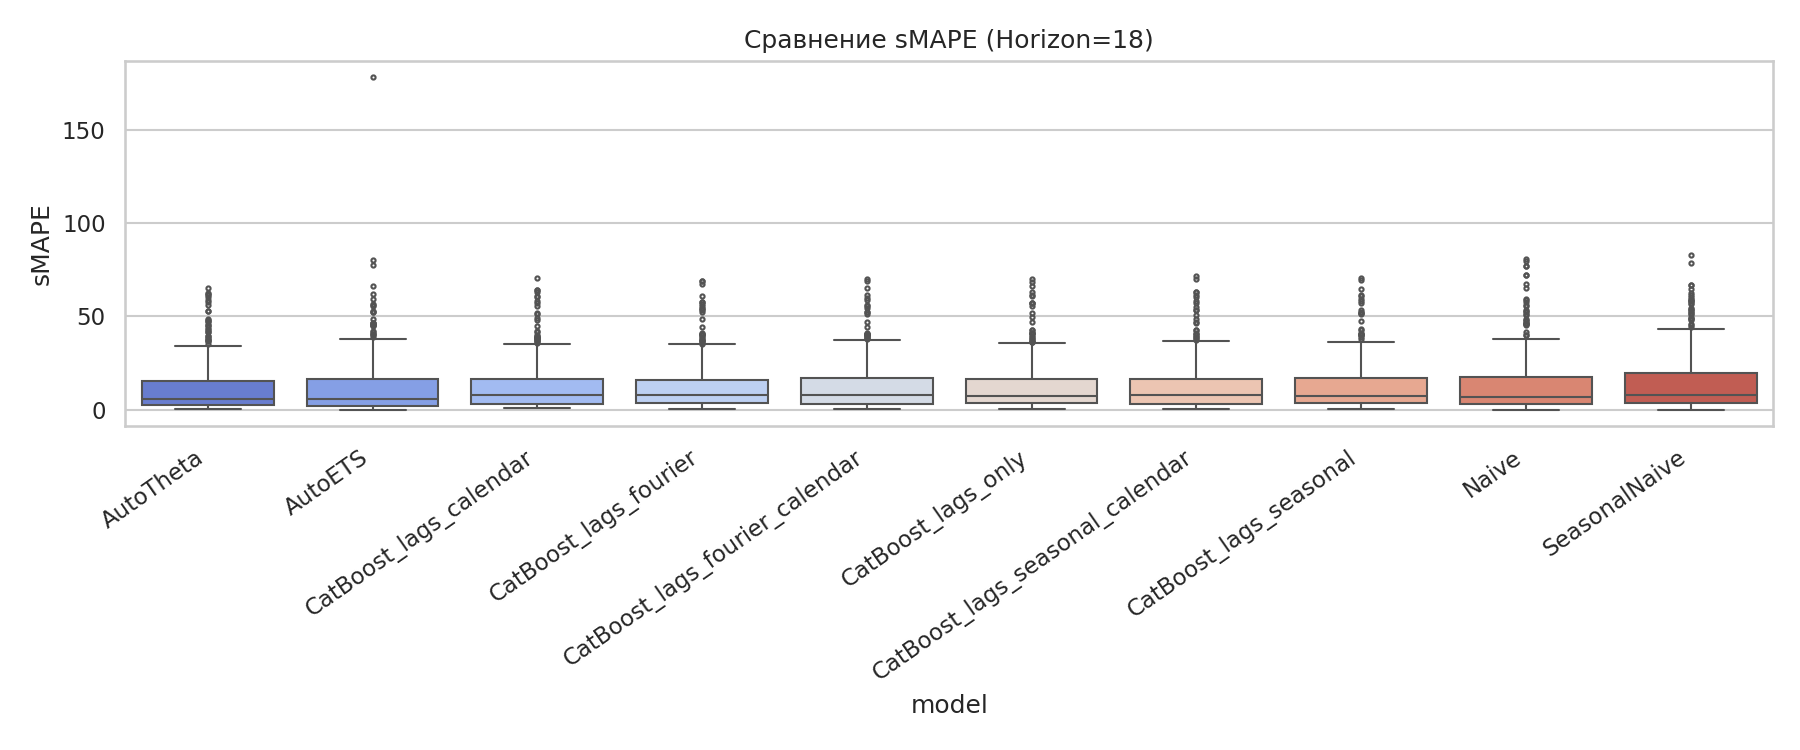

In [9]:
# график сравнения всех моделей (sMAPE)
print("\n Визуализация результатов ")
display (Image(filename=RESULTS / 'smape_comparison.png'))


 Визуализация результатов 


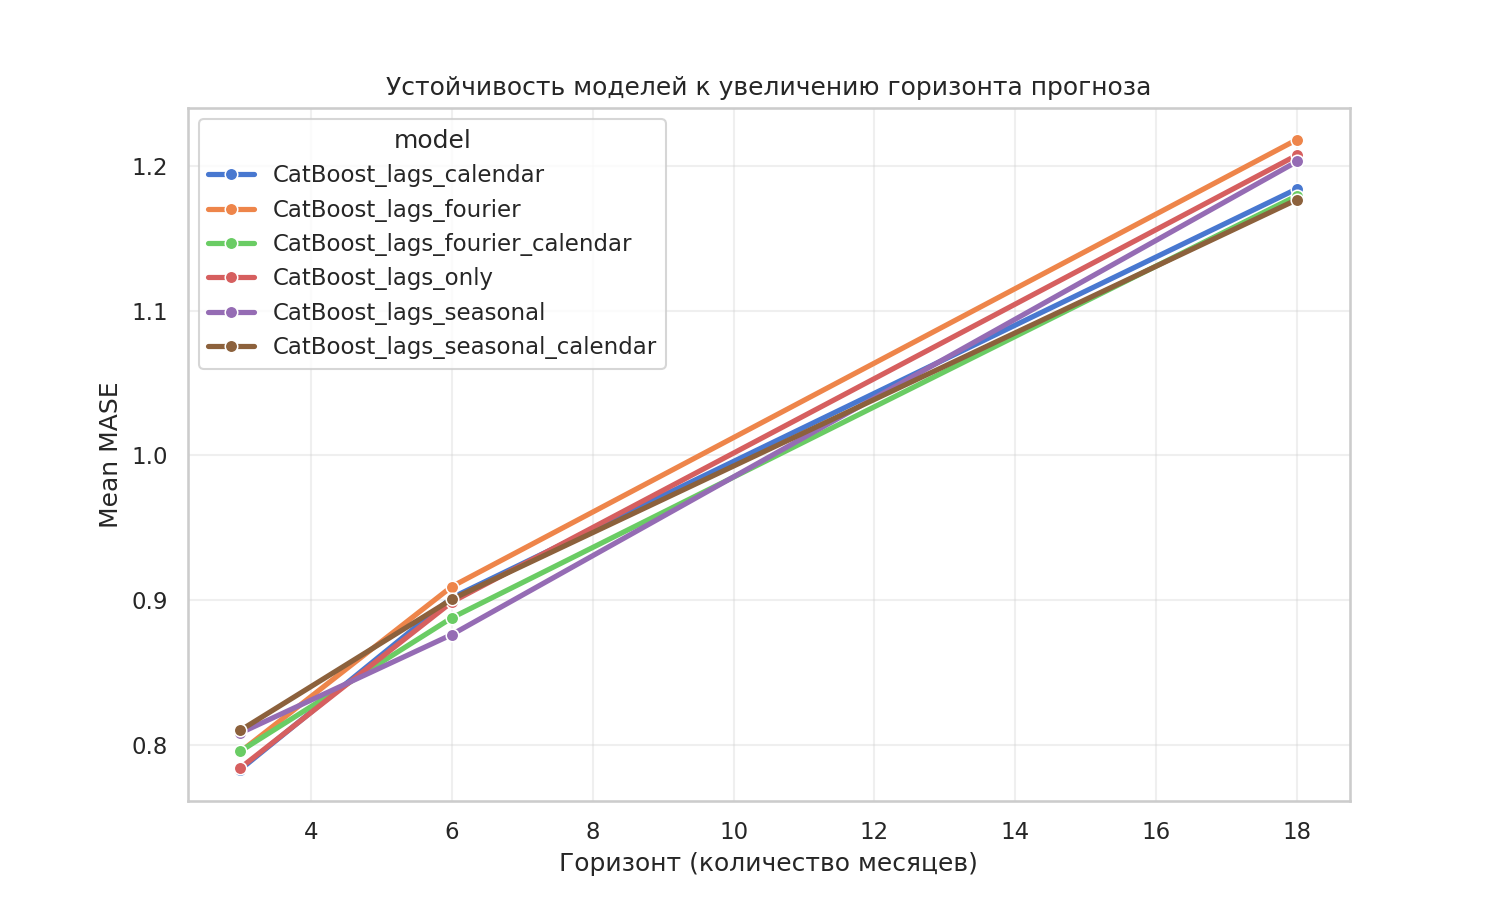

In [10]:
# устойчивость моделей к увеличению горизонта прогноза
print("\n Визуализация результатов ")
display (Image(filename=RESULTS / 'horizon_analysis_lineplot.png'))


 Визуализация результатов 


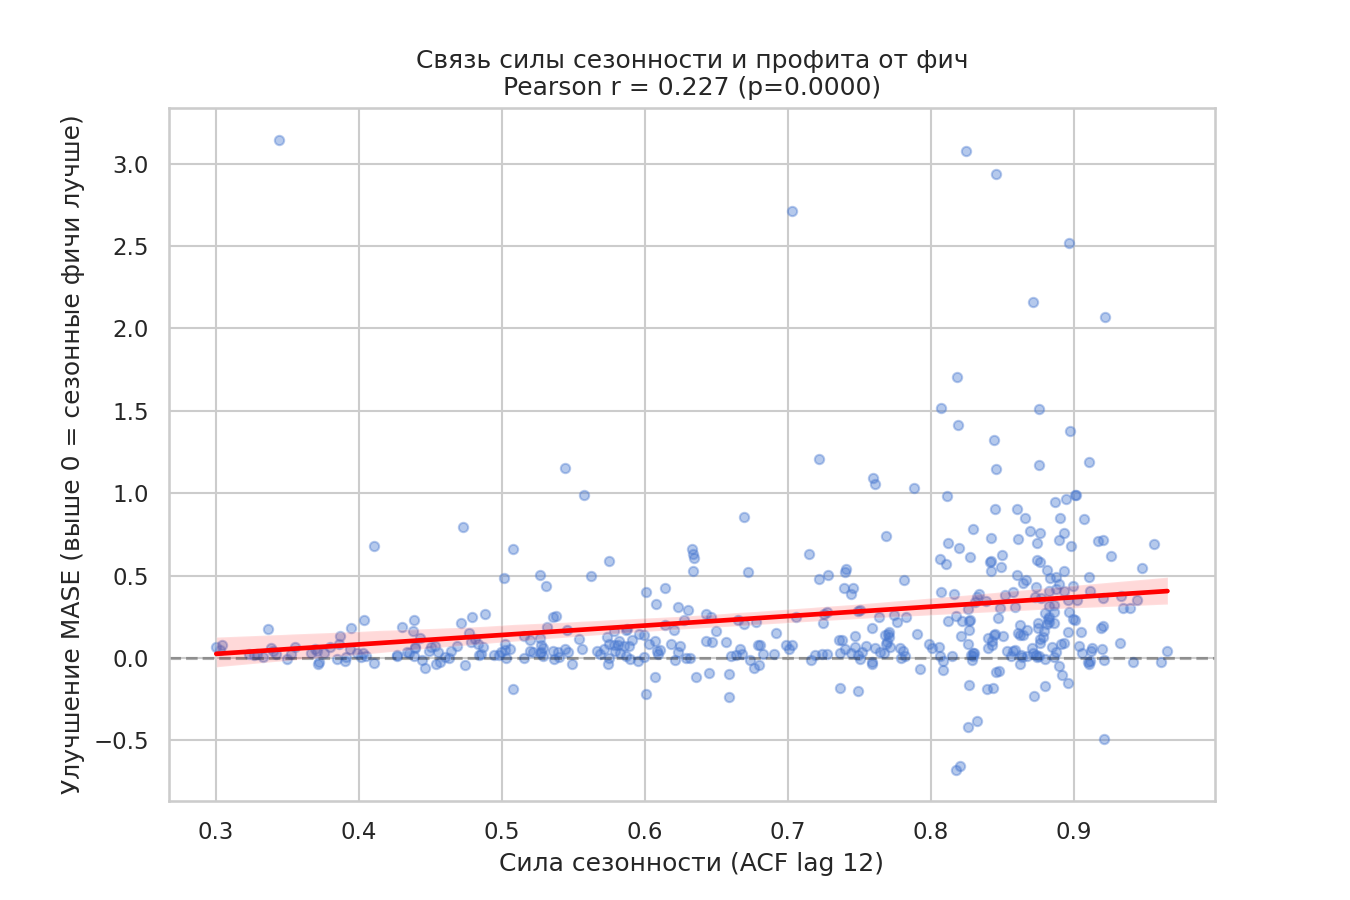

In [11]:
# график определения связи силы сезонности и профита от фич
print("\n Визуализация результатов ")
display (Image(filename=RESULTS / 'improvement_by_strength.png'))


 Визуализация результатов 


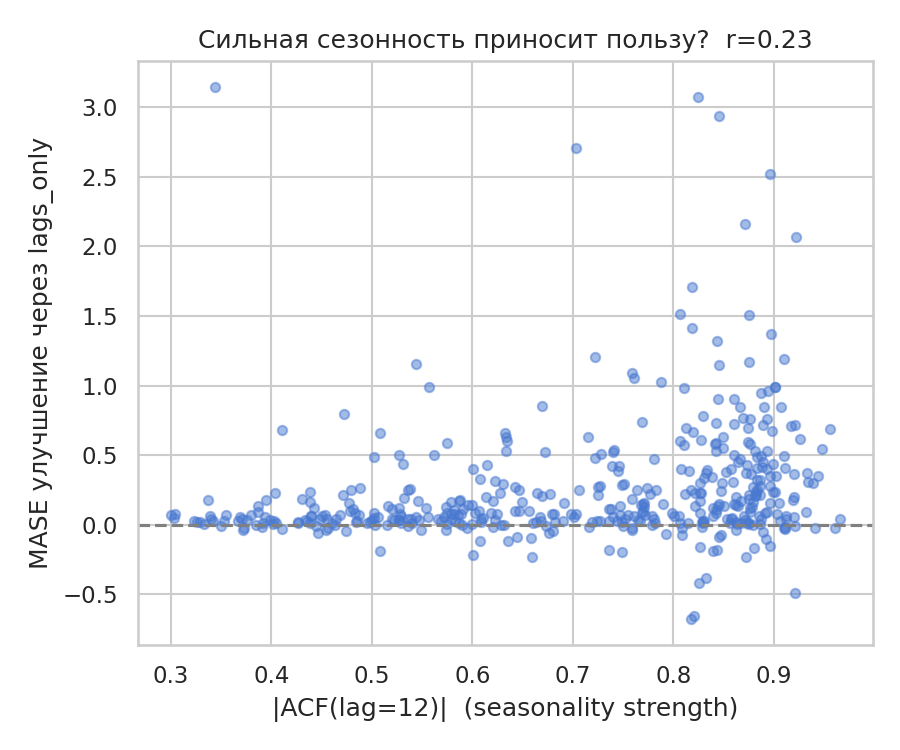

In [12]:
# график определения пользы сильной сезонности
print("\n Визуализация результатов ")
display (Image(filename=RESULTS / 'strength_vs_improvement.png'))

## 6. Отчет о проведенных экспериментах

### Принципы выбора метрик

| Метрика | Причина выбора |
|--------|-------------|
| **MASE** | Основная метрика. Не зависит от масштаба; MASE < 1 лучше наивного сезонного прогноза |
| **RMSSE** | Штрафует за большие ошибки; с помощью нее можно обнаружить смещения в данных |
| **sMAPE** | Процентная. Тоже нужна, но если близка к нулю то вводит в заблуждение |

Выбор только одной метрики будет неэффективным, так как:
- MASE чувствительна к выбросам в данных
- sMAPE могут быть проблемными при сериях близких к нулю
- RMSSE может сместить значения к нескольким большим ошибкам в расчетах

## Варианты фич

| Вариант | Описание |
|---------|-------------|
| `lags_only` | Прямые лаги авторегрессии |
| `lags_seasonal` | Лаги + сезонные лаги (lag 12, 24) |
| `lags_calendar` | Лаги + категориальные календарные фичи (месяц, квартал) |
| `lags_fourier` | Лаги + Фурье (sin/cos) |
| `lags_seasonal_calendar` | Комбо: сезонные лаги + календарные |
| `lags_fourier_calendar` | Комбо: Фурье + календарные |


## Проверяемые гипотезы

1. Помогают ли сезонные фичи (lags / calendar / Fourier) улучшить точность прогнозов по сравнению с прямыми лагами?
2. Выгодно ли полагаться на силу сезонности (слабые или сезонные ACF)?
3. Имеет ли важность горизонт прогнозирования (короткий на 3 месяца, средний на 6 месяцев или длинный на 18 месяцев)?


## Выводы
В рамках проекта на датасете M4 Monthly (438 рядов с видимой сезонностью из 500) на горизонтах short (h=3), medium (h=6) и long (h=18) установлено:
Классические модели AutoTheta и AutoETS значительно превосходят все глобальные модели CatBoost (преимущество 27% по MASE_mean на h=18).
Эксперимент на medium (h=6) и short (h=3) горизонте не произвёл никакого значимого эффекта и полностью подтвердил те же закономерности.
Добавление сезонных признаков (Фурье, календарь, сезонные лаги) дало небольшой эффект только на сильно сезонных рядах, однако общий результат глобальных моделей остаётся неудовлетворительным — они проигрывают даже простому Naive.
Основная причина — недостаточная способность сезонных фич эффективно передавать годовую сезонность в глобальной постановке на полученных данных.